In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"]=(8,5)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/aiexplorer77/gaming-vs-academic-performance/Gaming_Academic_Performance.csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/aiexplorer77/gaming-vs-academic-performance/Gaming_Academic_Performance.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   object 
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   object 
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   object 
 13  grades            8000 non-null   float64
dtypes: float64(9), int64(2), object(3)
memory usage: 875.1+ KB


In [4]:
df.describe()

,student_id,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,grades
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,19.983625,4.085773,5.460581,6.493453,79.886525,2.507790,7.586315,271.105839,9.908492,66.180776
std,2309.54541,2.587072,2.308801,2.575787,1.442656,11.580419,1.441128,2.710035,29.440675,5.035837,22.422024
min,1.00000,16.000000,0.000000,1.000000,4.000000,60.000000,0.000000,1.100000,183.260000,-4.510000,0.000000
25%,2000.75000,18.000000,2.130000,3.240000,5.240000,69.780000,1.287500,5.560000,247.160000,5.920000,49.879843
50%,4000.50000,20.000000,4.130000,5.460000,6.505000,79.695000,2.500000,7.610000,270.475000,10.005000,67.070000
75%,6000.25000,22.000000,6.060000,7.660000,7.730000,90.100000,3.760000,9.600000,294.690000,13.860000,83.992223
max,8000.00000,24.000000,8.000000,10.000000,9.000000,100.000000,5.000000,13.950000,347.870000,23.160000,118.632936


In [5]:
df.isnull().sum()

student_id          0
age                 0
gender              0
gaming_hours        0
study_hours         0
sleep_hours         0
attendance          0
gaming_genre        0
social_activity     0
device_usage        0
reaction_time_ms    0
addiction_score     0
stress_level        0
grades              0
dtype: int64

In [6]:
df['gender'].value_counts()
df['gaming_genre'].value_counts()
df['stress_level'].value_counts()

stress_level
Medium    4247
Low       2743
High      1010
Name: count, dtype: int64

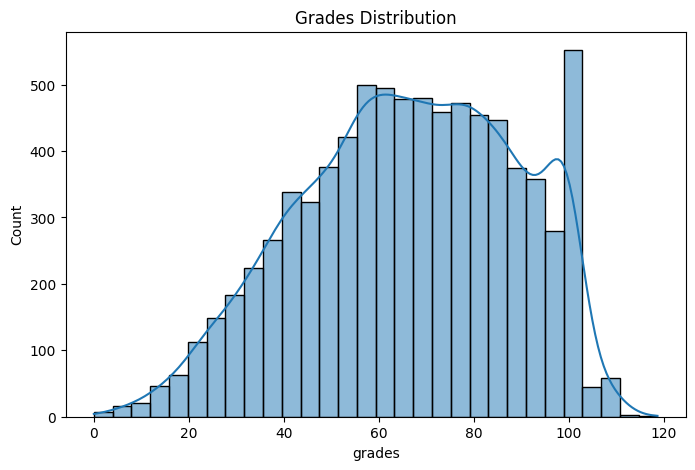

In [7]:
sns.histplot(df['grades'], bins=30, kde=True)
plt.title("Grades Distribution")
plt.show()

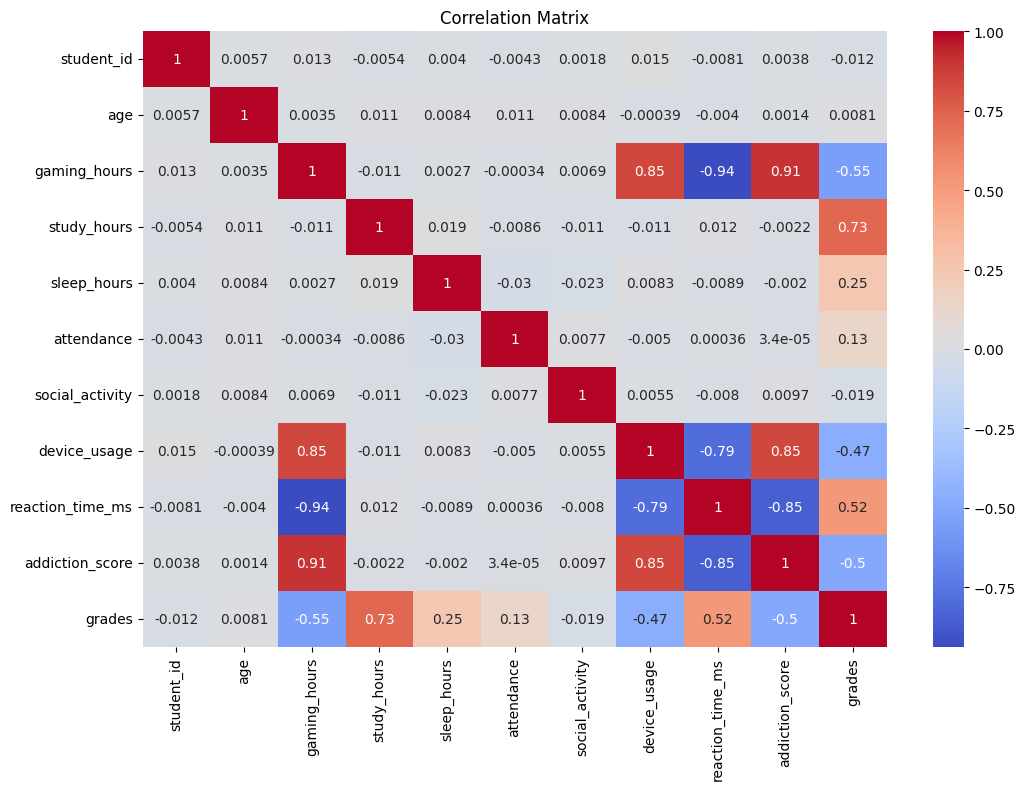

In [8]:
corr=df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

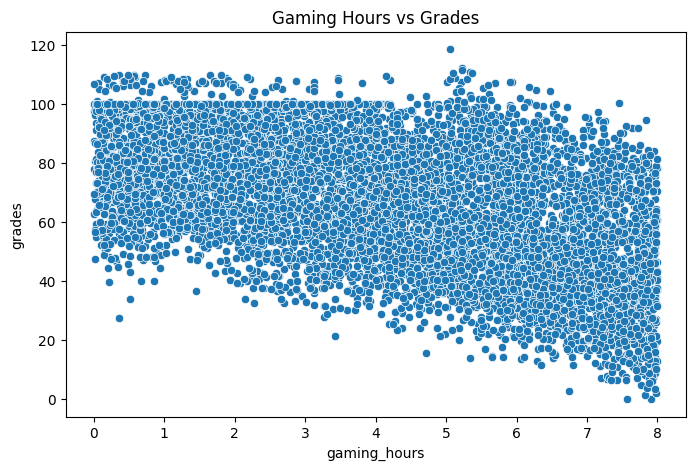

In [9]:
sns.scatterplot(x='gaming_hours', y='grades', data=df)
plt.title("Gaming Hours vs Grades")
plt.show()

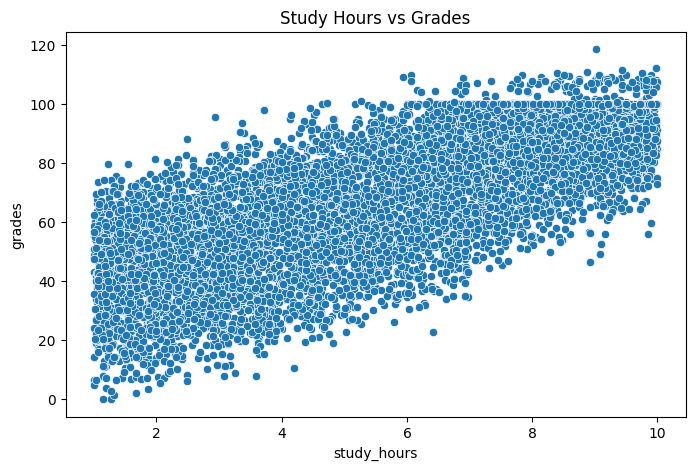

In [10]:
sns.scatterplot(x='study_hours', y='grades', data=df)
plt.title("Study Hours vs Grades")
plt.show()

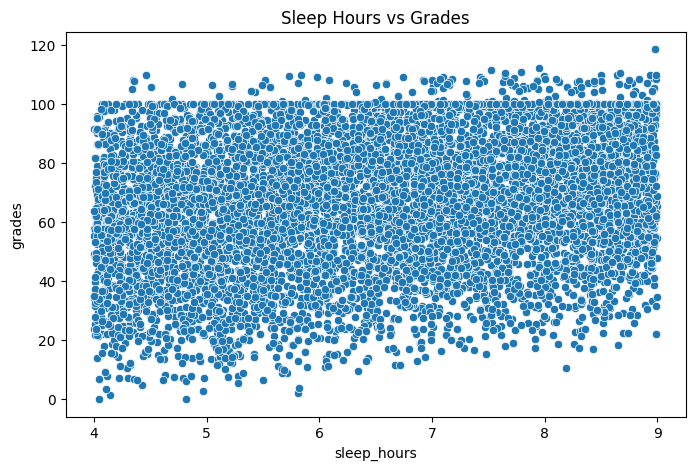

In [11]:
sns.scatterplot(x='sleep_hours', y='grades', data=df)
plt.title("Sleep Hours vs Grades")
plt.show()

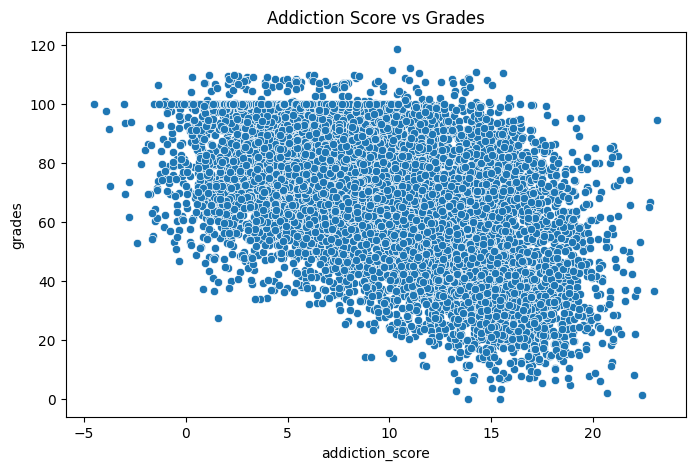

In [12]:
sns.scatterplot(x='addiction_score', y='grades', data=df)
plt.title("Addiction Score vs Grades")
plt.show()

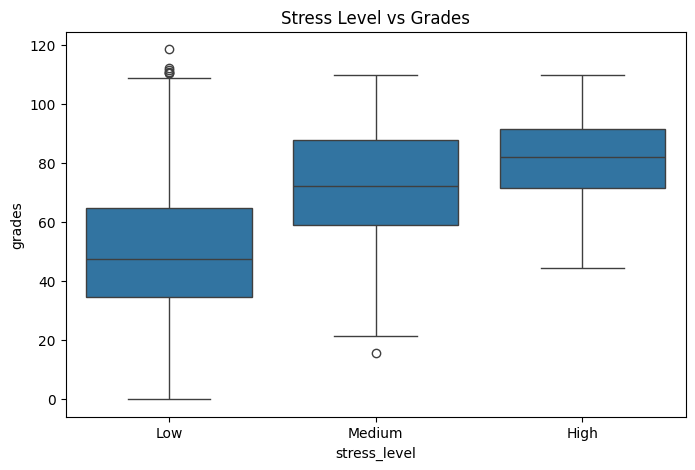

In [13]:
sns.boxplot(x='stress_level', y='grades', data=df)
plt.title("Stress Level vs Grades")
plt.show()

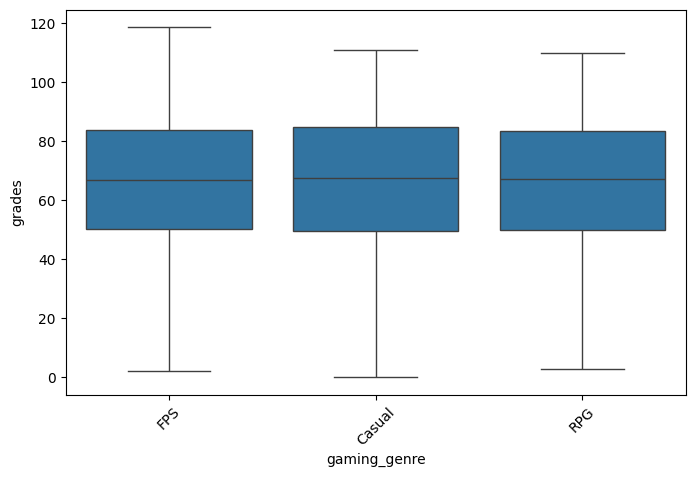

In [14]:
sns.boxplot(x='gaming_genre', y='grades', data=df)
plt.xticks(rotation=45)
plt.show()

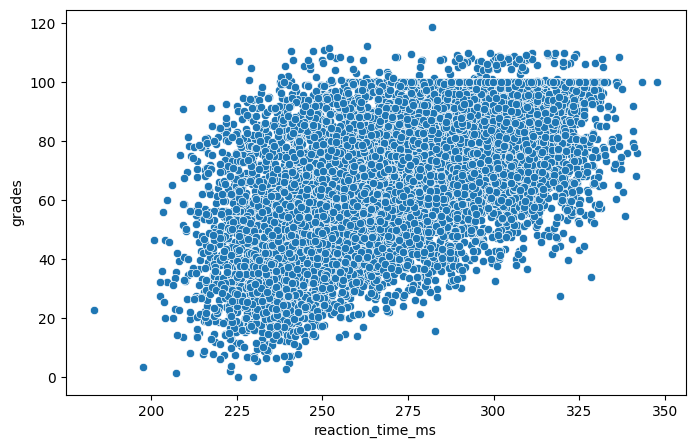

In [15]:
sns.scatterplot(x='reaction_time_ms', y='grades', data=df)
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

df_encoded=pd.get_dummies(df, drop_first=True)

X=df_encoded.drop(['grades', 'student_id'], axis=1)
y=df_encoded['grades']

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

model=RandomForestRegressor()
model.fit(X_train, y_train)

preds=model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))

MAE: 4.868781786744948


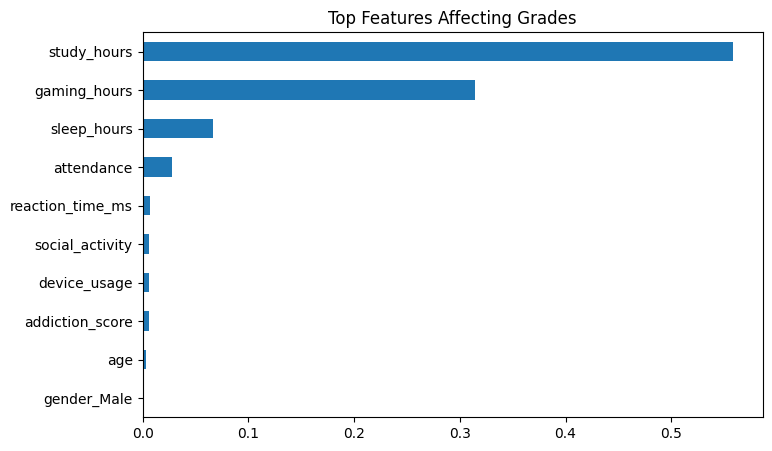

In [17]:
importance=pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().tail(10).plot(kind='barh')
plt.title("Top Features Affecting Grades")
plt.show()

📌 Key Insights

- Study hours show a strong positive correlation with academic performance.
- Gaming hours tend to negatively impact grades when exceeding moderate levels.
- Sleep plays a crucial role — both insufficient and excessive sleep reduce performance.
- Higher addiction scores are associated with lower academic outcomes.
- Stress level significantly affects grades, with high stress leading to poorer results.
- Attendance is one of the strongest predictors of academic success.
- Gaming genre shows minor variation, suggesting time spent is more important than type.
- Reaction time has a weak but interesting relationship with academic performance.

🎯 Conclusion

While gaming itself is not inherently harmful, excessive gaming combined with poor sleep and high stress can significantly reduce academic performance. Balanced habits are key to success.